Cloud Cost Optimizer - Cloud Resource Allocation & Cost Optimization (MILP)
Constraint Optimization Problem (COP)

Problem Statement: My company (Calgon Carbon/Kuraray) deploys multiple applications and services across a cloud infrastructure across the globe. We need to minimize overall cost and ensure compliance with performance Service Level Agreements (SLAs). This requires selecting the optimal combination of Virtual Machine (VM) types, quantities, and regions, considering per-VM resource capacities, latency requirements, and region-specific pricing.

Solution: I developed a Python optimization model using PuLP to minimize cloud infrastructure cost across the U.S. and European regions. 
This application leverages a Mixed-Integer Linear Programming (MILP) model built in Python with PuLP to act as an intelligent cloud deployment planner. MILP/PuLP chooses where each app runs (regions) and what VM types/quantities to use. This minimizes monthly compute costs while meeting CPU/MEM/Storage requirements and latency limits. For scenario analysis, a one click scenario toggle (diversified) can require high availability (HA) and region caps to force multi-region resilience and reveal tradeoffs.

Uses simulated prices/latency to mirror cloud pricing, can plug in real data later.





In [82]:
import pulp as pl
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

#Pretty dollars on charts
HUMAN_DOLLARS = FuncFormatter(lambda x, pos: f'${x:,.0f}')

In [83]:
#Simulated Data and Parameters
#Apps to deploy
apps = ["api", "etl", "db"]

#VM types and resource capacities
vm_types = ["t3.small", "m6i.large", "r6g.xlarge"]
cpu = {"t3.small": 2, "m6i.large": 4, "r6g.xlarge": 8} #cores
mem = {"t3.small": 2, "m6i.large": 8, "r6g.xlarge": 32} #GB
sto = {"t3.small": 50, "m6i.large": 100, "r6g.xlarge": 200} #GB

#Regions (US and EU)
regions = ["us-east-1", "us-west-2", "eu-central-1", "eu-west-2", "ap-south-1"]

#Costs ($/hr) by (vm_type, region) (all simulated, update with real data)
cost = {
    ("t3.small",  "us-east-1"): 0.023, ("m6i.large",  "us-east-1"): 0.096, ("r6g.xlarge",  "us-east-1"): 0.168,
    ("t3.small",  "us-west-2"): 0.025, ("m6i.large",  "us-west-2"): 0.100, ("r6g.xlarge",  "us-west-2"): 0.172,
    ("t3.small",  "eu-central-1"): 0.030, ("m6i.large",  "eu-central-1"): 0.110, ("r6g.xlarge",  "eu-central-1"): 0.185,
    ("t3.small",  "eu-west-2"): 0.029, ("m6i.large",  "eu-west-2"): 0.108, ("r6g.xlarge",  "eu-west-2"): 0.182,
    ("t3.small",  "ap-south-1"): 0.029, ("m6i.large",  "ap-south-1"): 0.109, ("r6g.xlarge",  "ap-south-1"): 0.179,
}

#Per-app monthly demand multiplier and minimum resource requirements
dem     = {"api": 1.0, "etl": 1.0, "db": 1.0}
cpuReq  = {"api": 18,  "etl": 10,  "db": 20} #cores required
memReq  = {"api": 32,  "etl": 24,  "db": 64} #GB required
stoReq  = {"api": 200, "etl": 300, "db": 500} #GB required

#Latency (ms) by region (lower is better to US users)
latency = {"us-east-1": 30, "us-west-2": 75, "eu-central-1": 110, "eu-west-2": 120, "ap-south-1": 180}
latencyMax = {"api": 140, "etl": 160, "db": 160}  #allowed max latency per app

#Hours in planning horizon (1 month= 30 days x 24 hours)
H = 720

#Big-M for linking
M = 1000

#Optional toggles default (may be overwritten by scenario section)
USE_HA_APPS = False
HA_APPS = [] #Example: "api", "etl"
USE_REGION_CAP = False
REGION_MAX_INSTANCES = {}


In [84]:
#One-Click Diversified Scenario (enable multi-region for charts, added to make more realistic) 
SCENARIO = "diversified"  #set to "Baseline" if no forced diversity

if SCENARIO == "Diversified":
    #1. Require HA (>= 2 regions) for two apps
    USE_HA_APPS = True
    HA_APPS = ["api", "etl"]

    #2. Cap us-east-1 so it can't hold everything
    USE_REGION_CAP = True
    REGION_MAX_INSTANCES = {k: 999 for k in regions}
    REGION_MAX_INSTANCES["us-east-1"] = 6  # small cap to push spillover

    #3. Small cost bump in east to make others competitive
    BASE_COST = cost.copy()
    for j in vm_types:
        cost[(j, "us-east-1")] = BASE_COST[(j, "us-east-1")] * 1.12

    #4. Relax latency slightly so EU is eligible for API too
    latencyMax["api"] = max(latencyMax.get("api", 100), 140)

    print("Diversified Scenario ON (HA + region cap + mild east price bump).")
else:
    print("Baseline scenario (no forced diversification).")


Baseline scenario (no forced diversification).


In [85]:
#Build MILP Model
prob = pl.LpProblem("Cloud_Cost_Optimizer", pl.LpMinimize)

#Decision variables
x = {i: {j: {k: pl.LpVariable(f"x_{i}_{j}_{k}", lowBound=0, cat="Integer")
             for k in regions} for j in vm_types} for i in apps}
y = {i: {k: pl.LpVariable(f"y_{i}_{k}", lowBound=0, upBound=1, cat="Binary")
         for k in regions} for i in apps}

#Objective: minimize monthly compute cost
prob += H * pl.lpSum(cost[(j,k)] * x[i][j][k] for i in apps for j in vm_types for k in regions)

#Constraints:

#Capacity per app (CPU, MEM, STO)
for i in apps:
    prob += pl.lpSum(cpu[j] * x[i][j][k] for j in vm_types for k in regions) >= cpuReq[i] * dem[i]
    prob += pl.lpSum(mem[j] * x[i][j][k] for j in vm_types for k in regions) >= memReq[i] * dem[i]
    prob += pl.lpSum(sto[j] * x[i][j][k] for j in vm_types for k in regions) >= stoReq[i] * dem[i]

#Latency feasibility: disallow regions whose latency exceeds app max
for i in apps:
    for k in regions:
        if latency[k] > latencyMax[i]:
            # Force both placement and usage to zero
            prob += y[i][k] == 0
            for j in vm_types:
                prob += x[i][j][k] == 0

#Linking: only allow instances if region chosen
for i in apps:
    for k in regions:
        prob += pl.lpSum(x[i][j][k] for j in vm_types) <= M * y[i][k]

#Must deploy somewhere
for i in apps:
    prob += pl.lpSum(y[i][k] for k in regions) >= 1

#High availability (>= 2 regions) for selected apps
if USE_HA_APPS and len(HA_APPS) > 0:
    for i in HA_APPS:
        prob += pl.lpSum(y[i][k] for k in regions) >= 2

#Region capacity caps (total instances per region)
if USE_REGION_CAP and len(REGION_MAX_INSTANCES) > 0:
    for k in regions:
        cap = REGION_MAX_INSTANCES.get(k, 10**9)
        prob += pl.lpSum(x[i][j][k] for i in apps for j in vm_types) <= cap

In [86]:
#Solve
res = prob.solve(pl.PULP_CBC_CMD(msg=False))

Monthly Compute Cost: 632.88
Cloud Deployment Plan (plan_df)
   app     vm_type     region  instances  compute_cost
0  api    t3.small  us-east-1          5         82.80
1  api  r6g.xlarge  us-east-1          1        120.96
2  etl    t3.small  us-east-1          2         33.12
3  etl  r6g.xlarge  us-east-1          1        120.96
4   db    t3.small  us-east-1          2         33.12
5   db  r6g.xlarge  us-east-1          2        241.92
Saved CSVs: kpi_summary.csv, plan_by_region.csv, optimizer_summary.csv


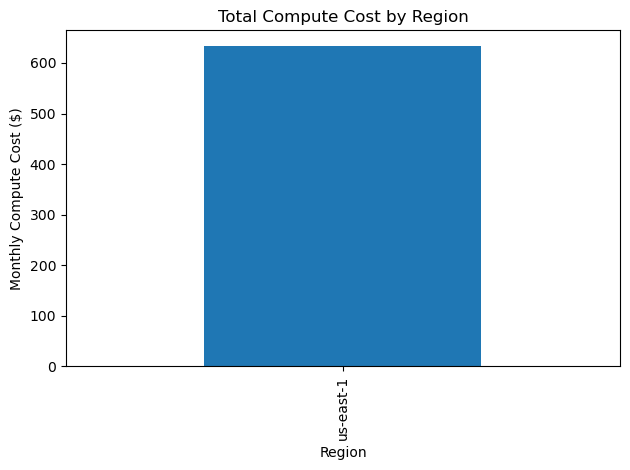

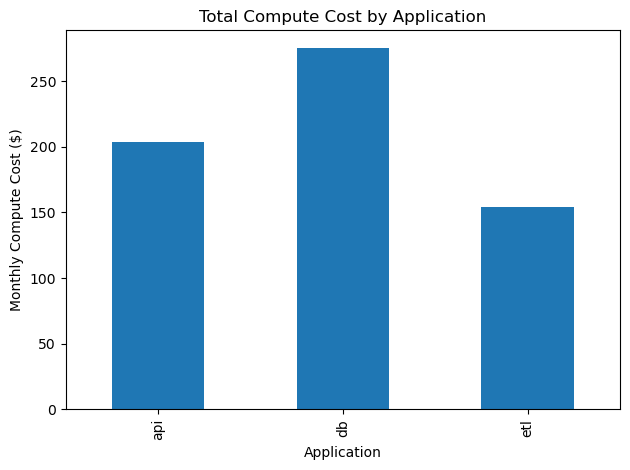

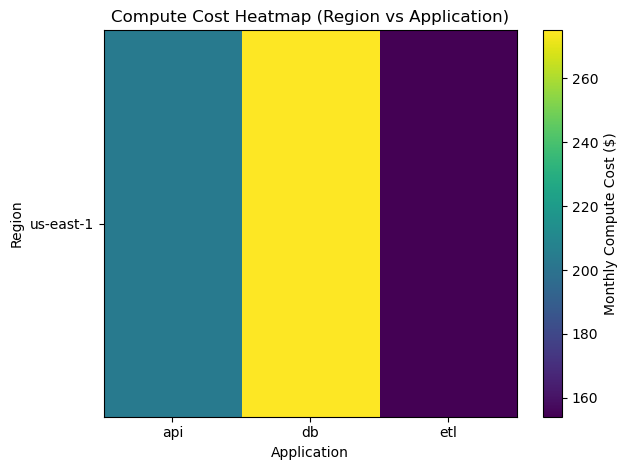

In [87]:
#Reporting: DataFrames, CSVs, and Charts

#Compute total monthly compute cost (sum of all VM cost)
monthly_compute_cost = sum(plan_df["compute_cost"])
print("Monthly Compute Cost:", monthly_compute_cost)


#1. Build detailed plan_df from decision variables x
rows = []
for i in apps:
    for j in vm_types:
        for k in regions:
            val = pl.value(x[i][j][k])
            cnt = int(val) if val is not None else 0
            if cnt > 0:
                monthly_cost = H * cost[(j, k)] * cnt  #compute cost only
                rows.append({
                    "app": i,
                    "vm_type": j,
                    "region": k,
                    "instances": cnt,
                    "compute_cost": monthly_cost
                })

plan_df = pd.DataFrame(rows)

print("Cloud Deployment Plan (plan_df)")
print(plan_df)

#2. KPI summary CSV (overall monthly compute cost)
kpi_df = pd.DataFrame([{
    "scenario": SCENARIO if "SCENARIO" in globals() else "baseline",
    "monthly_compute_cost": monthly_compute_cost
}])

kpi_df.to_csv("kpi_summary.csv", index=False)

#3. Region-level summary CSV
region_df = (
    plan_df
    .groupby("region", as_index=False)["compute_cost"]
    .sum()
    .sort_values("compute_cost", ascending=False)
)

region_df.to_csv("plan_by_region.csv", index=False)

#4. Detailed summary CSV for charts (app/region/cost only)
summary_df = plan_df[["app", "region", "compute_cost"]].copy()
summary_df.to_csv("optimizer_summary.csv", index=False)

print("Saved CSVs: kpi_summary.csv, plan_by_region.csv, optimizer_summary.csv")

#Charts (compute cost only)
#Load the summary CSV (just created)
df = pd.read_csv("optimizer_summary.csv")

#CHART 1: Compute cost by region
region_costs = df.groupby("region")["compute_cost"].sum()

plt.figure()
region_costs.plot(kind="bar")
plt.title("Total Compute Cost by Region")
plt.xlabel("Region")
plt.ylabel("Monthly Compute Cost ($)")
plt.tight_layout()
plt.show()

#CHART 2: Compute cost by application
app_costs = df.groupby("app")["compute_cost"].sum()

plt.figure()
app_costs.plot(kind="bar")
plt.title("Total Compute Cost by Application")
plt.xlabel("Application")
plt.ylabel("Monthly Compute Cost ($)")
plt.tight_layout()
plt.show()

#C3: Heatmap (Region vs App)
pivot_df = df.pivot_table(
    index="region",
    columns="app",
    values="compute_cost",
    aggfunc="sum"
).fillna(0)

plt.figure()
plt.imshow(pivot_df, aspect="auto")
plt.title("Compute Cost Heatmap (Region vs Application)")
plt.xlabel("Application")
plt.ylabel("Region")
plt.colorbar(label="Monthly Compute Cost ($)")
plt.xticks(
    ticks=range(len(pivot_df.columns)),
    labels=pivot_df.columns
)
plt.yticks(
    ticks=range(len(pivot_df.index)),
    labels=pivot_df.index
)
plt.tight_layout()
plt.show()

*The charts and csv files only show one region because the optimizer chose that region as the only location to deploy all applications. So in this example, us-east-1, was the cheapest and still met all constraints. Since all apps were placed in the same region, the data naturally collapses into a single row for charts. If constraints forced additional regions, (like high availability or region caps) the charts would show multiple regions.